In [24]:
import torchvision.models as models
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [25]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.4),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

In [26]:
train_dataset = datasets.ImageFolder(root="Data_helmet_detection_CNN/train", transform=transform)
val_dataset = datasets.ImageFolder(root="Data_helmet_detection_CNN/valid", transform=transform)
test_dataset = datasets.ImageFolder(root="Data_helmet_detection_CNN/test", transform=transform)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.vgg16(pretrained=True)

In [28]:
class_counts = torch.tensor([887, 3711], dtype=torch.float32)
class_weights = class_counts.sum() / class_counts  
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights[0].to(device))
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

In [29]:
from torch.utils.data import WeightedRandomSampler

weights = [1/class_counts[label] for _, label in train_dataset]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

In [30]:
train_loader = DataLoader(train_dataset, batch_size=40,sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=40, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=40, shuffle=False)

In [31]:
for param in model.features.parameters():
    param.requires_grad = False

In [32]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [33]:
print(model.classifier[6])

Linear(in_features=4096, out_features=1000, bias=True)


In [34]:
model.classifier[6] = nn.Linear(4096,1,bias=True)
model.classifier.add_module("sigmoid", nn.Sigmoid()) 
model = model.to(device)

In [35]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [36]:
print(train_dataset.class_to_idx)

{'helmet': 0, 'no_helmet': 1}


In [37]:
epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Training phase
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        labels = labels.float().unsqueeze(1)  # Reshape labels to [batch_size, 1]
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predicted = (outputs > 0.5).float()  # Convert probabilities to binary predictions
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # Calculate training loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total * 100
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_accuracy:.2f}%')

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            labels = labels.float().unsqueeze(1)  # Reshape labels to [batch_size, 1]
            loss = loss_fn(outputs, labels)
            val_running_loss += loss.item()
            predicted = (outputs > 0.5).float()  # Convert probabilities to binary predictions
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    # Calculate validation loss and accuracy
    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_accuracy = val_correct / val_total * 100
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)
    print(f'Epoch {epoch+1}/{epochs}, Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_epoch_accuracy:.2f}%')

Epoch 1/10, Training Loss: 0.8562, Training Accuracy: 94.04%
Epoch 1/10, Validation Loss: 1.4302, Validation Accuracy: 77.66%
Epoch 2/10, Training Loss: 0.8483, Training Accuracy: 94.65%
Epoch 2/10, Validation Loss: 1.4302, Validation Accuracy: 77.66%
Epoch 3/10, Training Loss: 0.8509, Training Accuracy: 94.56%
Epoch 3/10, Validation Loss: 1.4302, Validation Accuracy: 77.66%
Epoch 4/10, Training Loss: 0.8363, Training Accuracy: 95.06%
Epoch 4/10, Validation Loss: 1.4302, Validation Accuracy: 77.66%
Epoch 5/10, Training Loss: 0.8571, Training Accuracy: 94.35%
Epoch 5/10, Validation Loss: 1.4302, Validation Accuracy: 77.66%
Epoch 6/10, Training Loss: 0.8464, Training Accuracy: 94.72%
Epoch 6/10, Validation Loss: 1.4302, Validation Accuracy: 77.66%
Epoch 7/10, Training Loss: 0.8508, Training Accuracy: 94.56%
Epoch 7/10, Validation Loss: 1.4302, Validation Accuracy: 77.66%
Epoch 8/10, Training Loss: 0.8590, Training Accuracy: 94.28%
Epoch 8/10, Validation Loss: 1.4302, Validation Accuracy:

In [38]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

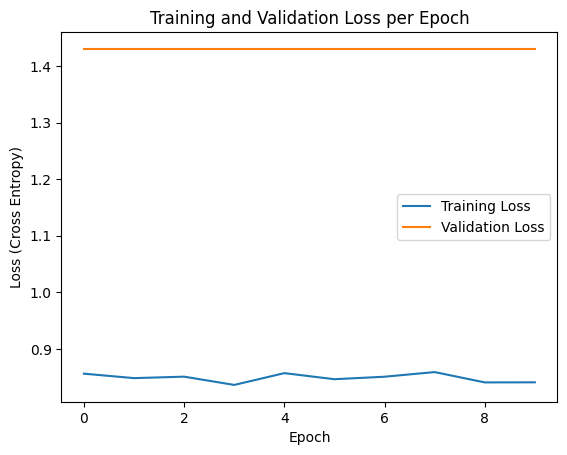

In [39]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.show()

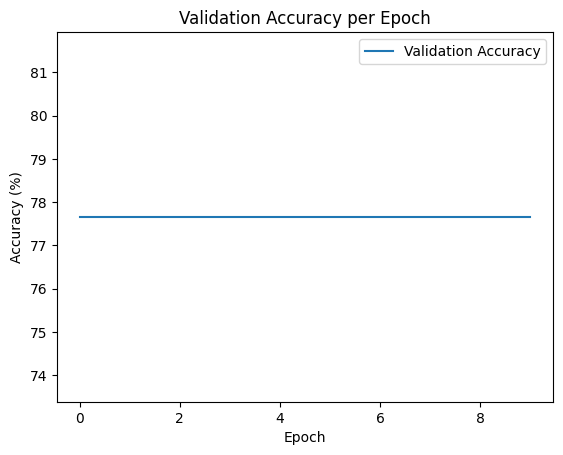

In [40]:
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

In [41]:
model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)  
        labels = torch.Tensor.cpu(labels)
        labels = labels.float().unsqueeze(1)  
        predicted = (outputs > 0.5).float()
        predicted = torch.Tensor.cpu(predicted)
        all_labels.extend(labels.squeeze().numpy())  
        all_predictions.extend(predicted.squeeze().numpy())  

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total * 100
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 81.70%


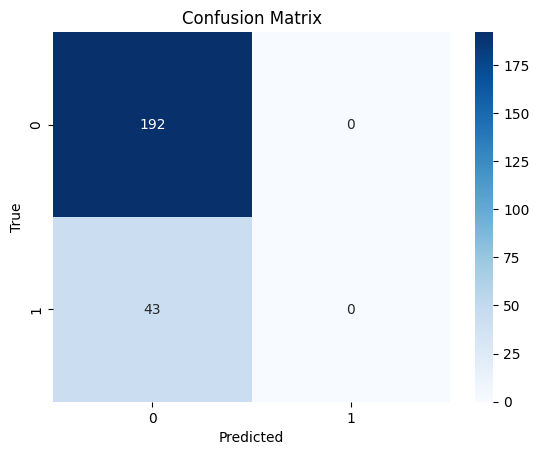

In [42]:
class_labels = test_dataset.class_to_idx.values()

cm = confusion_matrix(all_labels, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [61]:
report = classification_report(all_labels, all_predictions)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      1.00      0.90       192
         1.0       0.00      0.00      0.00        43

    accuracy                           0.82       235
   macro avg       0.41      0.50      0.45       235
weighted avg       0.67      0.82      0.73       235



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
torch.save(model, "models/vgg16_helmet_classification.pth")